Data Sanity Notebook

In [1]:
from pathlib import Path
import sys
import torch
import matplotlib.pyplot as plt

p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "scripts").exists())
sys.path.insert(0, str(repo_root / "scripts"))

In [2]:
from voc_datasets import build_voc_datasets, VOC_CLASSES, IGNORE_INDEX

In [3]:
train_dataset, val_dataset = build_voc_datasets(
    root = "c:/Users/Kwame Boateng/Documents/GitHub/semantic-segmentation/Data",
    img_size = 256
    )

c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [4]:
print(f'Train Samples: {len(train_dataset)}')
print(f'Validation Samples: {len(val_dataset)}')

Train Samples: 209
Validation Samples: 213


In [5]:
def show_sample(image, mask, class_names):
    # Convert image: (C,H,W) → (H,W,C)
    image = image.permute(1, 2, 0).cpu().numpy()

    # Convert mask to numpy
    mask_np = mask.cpu().numpy()

    # Create a copy for visualization
    vis_mask = mask_np.copy()

    # Replace ignore index (255) → background (0) ONLY for display
    vis_mask[vis_mask == 255] = 0

    plt.figure(figsize=(10, 4))

    # Image
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    # Mask
    plt.subplot(1, 2, 2)
    im = plt.imshow(vis_mask, cmap="tab20", vmin=0, vmax=20)
    plt.title("Mask (visualized)")
    plt.axis("off")

    # Colorbar with class labels
    cbar = plt.colorbar(im, ticks=range(21))
    cbar.ax.set_yticklabels([f"{i}: {class_names[i]}" for i in range(21)])
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

In [6]:
image, mask = train_dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image dtype:", image.dtype)
print("Mask dtype:", mask.dtype)
print("Image min:", image.min().item(), "Image max:", image.max().item())
print("Mask unique values:", torch.unique(mask))

Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([256, 256])
Image dtype: torch.float32
Mask dtype: torch.int64
Image min: 0.003921568859368563 Image max: 1.0
Mask unique values: tensor([  0,   1,  15, 255])


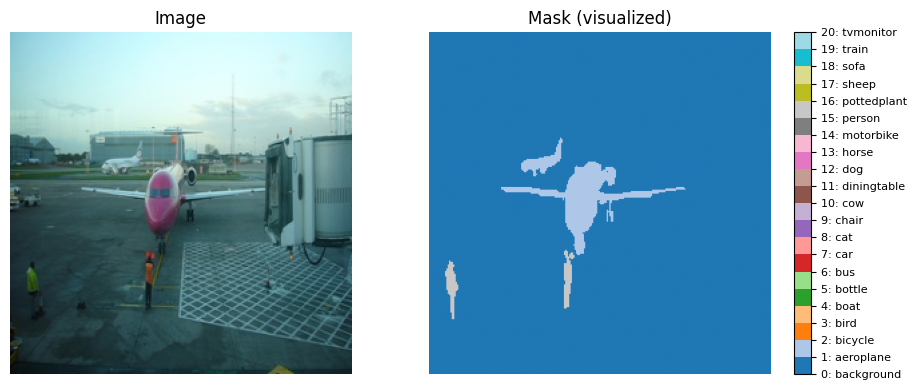

In [7]:
show_sample(image, mask, VOC_CLASSES)


In [8]:
for i in range(5):
    image, mask = train_dataset[i]
    print(f"Sample {i}")
    print("  image shape:", image.shape)
    print("  mask shape:", mask.shape)
    print("  unique mask values:", torch.unique(mask).tolist())
    print()

Sample 0
  image shape: torch.Size([3, 256, 256])
  mask shape: torch.Size([256, 256])
  unique mask values: [0, 1, 15, 255]

Sample 1
  image shape: torch.Size([3, 256, 256])
  mask shape: torch.Size([256, 256])
  unique mask values: [0, 1, 255]

Sample 2
  image shape: torch.Size([3, 256, 256])
  mask shape: torch.Size([256, 256])
  unique mask values: [0, 19, 255]

Sample 3
  image shape: torch.Size([3, 256, 256])
  mask shape: torch.Size([256, 256])
  unique mask values: [0, 4, 255]

Sample 4
  image shape: torch.Size([3, 256, 256])
  mask shape: torch.Size([256, 256])
  unique mask values: [0, 2, 15, 255]



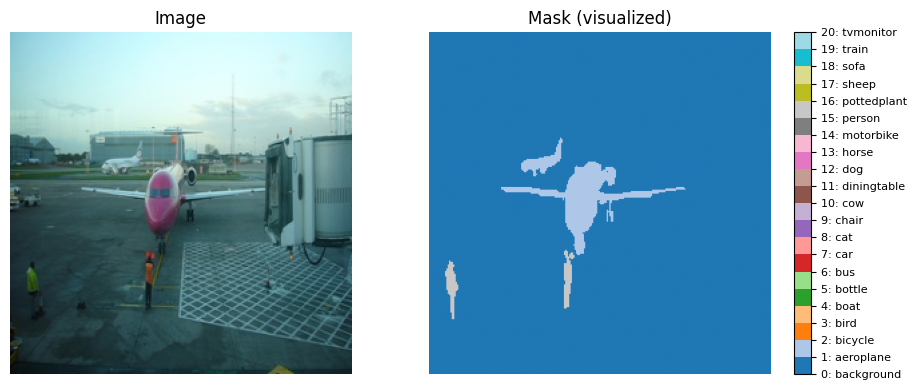

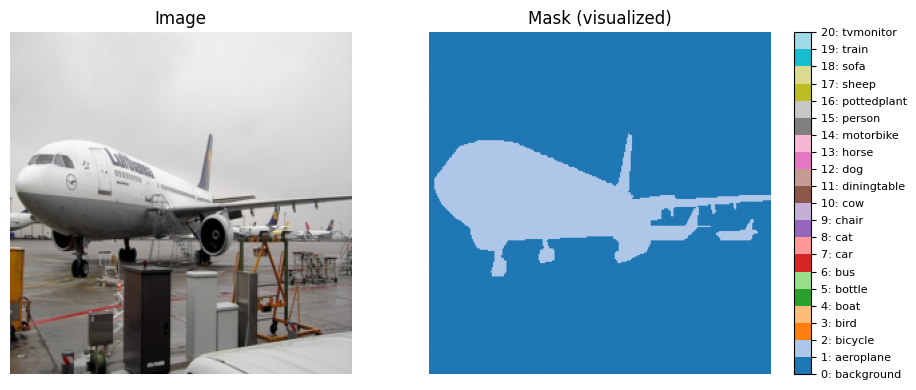

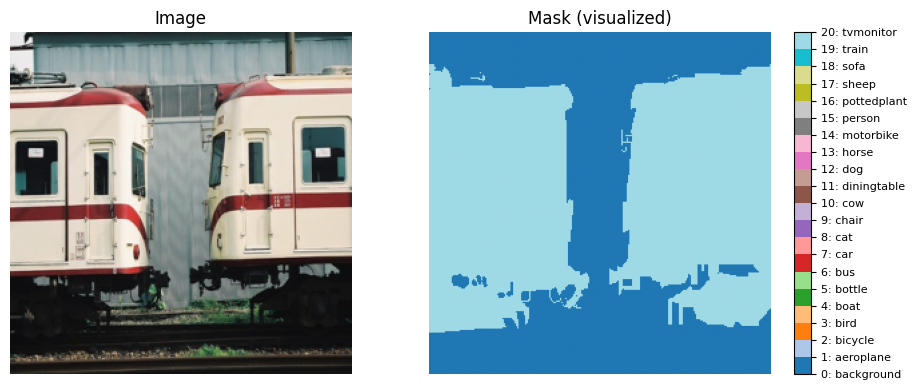

In [12]:
num_samples = 3

for i in range(num_samples):
    image, mask = train_dataset[i]
    show_sample(image, mask, VOC_CLASSES)

In [10]:
found_ignore = False

for i in range(len(train_dataset)):
    _, mask = train_dataset[i]
    if IGNORE_INDEX in torch.unique(mask):
        print(f"Found ignore index {IGNORE_INDEX} in sample {i}")
        found_ignore = True
        break

if not found_ignore:
    print(f"No ignore index {IGNORE_INDEX} found in checked samples")

Found ignore index 255 in sample 0


In [11]:
from collections import Counter

counter = Counter()

num_check = min(20, len(train_dataset))

for i in range(num_check):
    _, mask = train_dataset[i]
    counter.update(mask.flatten().tolist())

print("Raw label counts over first", num_check, "samples:")
for label, count in sorted(counter.items()):
    if label == IGNORE_INDEX:
        name = "ignore"
    else:
        name = VOC_CLASSES[label]
    print(f"{label:>3} ({name}): {count}")

Raw label counts over first 20 samples:
  0 (background): 893337
  1 (aeroplane): 20583
  2 (bicycle): 14141
  4 (boat): 4184
  5 (bottle): 3825
  6 (bus): 53914
  7 (car): 63
  8 (cat): 55288
  9 (chair): 7980
 10 (cow): 1262
 11 (diningtable): 27347
 13 (horse): 3126
 14 (motorbike): 19427
 15 (person): 74086
 18 (sofa): 6179
 19 (train): 36614
 20 (tvmonitor): 31910
255 (ignore): 57454
